present min -52.3 max 32.2 mean -2.8
holocene min -52.6 max 30.1 mean -3.5
lgm min -79.9 max 27.3 mean -15.1


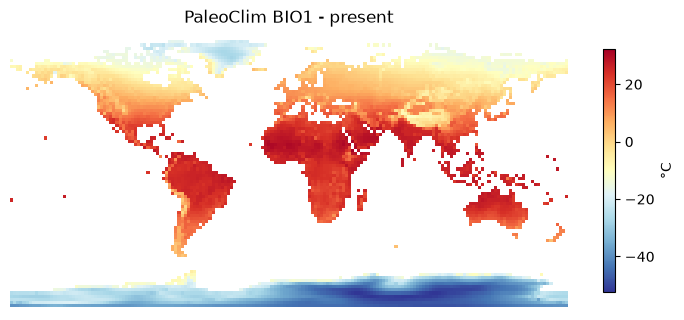

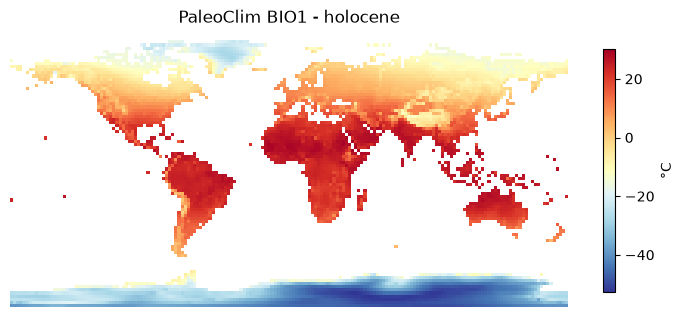

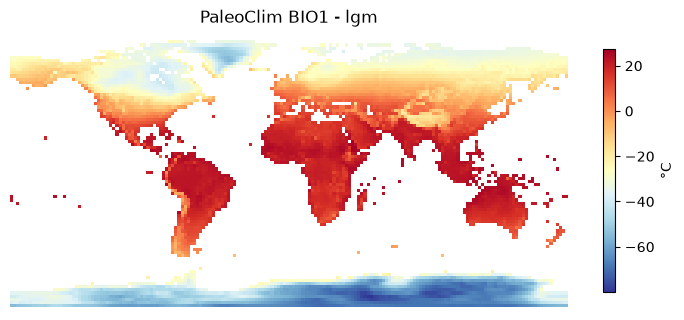

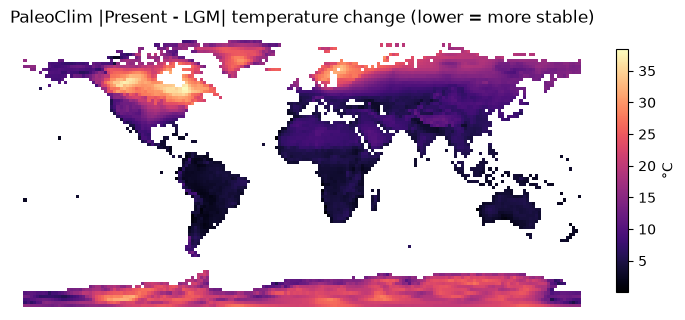

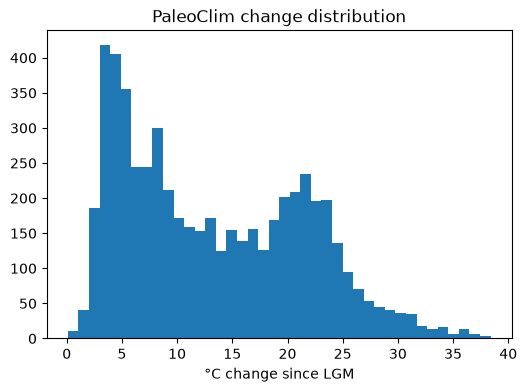

(375, 8)


,cell_lat,cell_lon,pc_present,pc_holocene,pc_lgm,pc_lgm_change,pc_holo_change,pc_instability
0,-52.5,-72.5,5.290000,4.460000,-5.062430,10.352430,0.830000,5.753403
1,-52.5,-67.5,4.478947,3.894737,-4.774871,9.253818,0.584211,5.182360
2,-52.5,167.5,8.300000,7.400000,3.699500,4.600500,0.900000,2.438179
3,-47.5,-72.5,4.087500,3.275000,-3.638649,7.726149,0.812500,4.246988
4,-47.5,167.5,8.250000,7.700000,4.733250,3.516750,0.550000,1.891813


In [1]:
import sys
sys.path.append("..")

from common.helpers import *


pts = pd.read_csv("../GBIF/processed/gbif_points_clean.csv")

P = {
    "present": "raw/paleoclim_current_BIO1.tif",
    "holocene": "raw/paleoclim_late_holocene_BIO1_aligned.tif",
    "lgm": "raw/paleoclim_LGM_BIO1_aligned.tif"
}


grids = {
    k: global_grid(v)
    for k, v in P.items()
}


# Sanity check: values should be roughly -50 to 35 °C
for k, g in grids.items():
    print(
        k,
        "min", np.nanmin(g).round(1),
        "max", np.nanmax(g).round(1),
        "mean", np.nanmean(g).round(1)
    )


for k, g in grids.items():
    plot_map(
        g,
        f"PaleoClim BIO1 - {k}",
        "°C",
        f"figures/pc_bio1_{k}.png",
        "RdYlBu_r"
    )


diff = np.abs(
    grids["present"] - grids["lgm"]
)

plot_map(
    diff,
    "PaleoClim |Present - LGM| temperature change (lower = more stable)",
    "°C",
    "figures/pc_lgm_change.png",
    "magma"
)

np.save(
    "processed/pc_lgm_change_2deg.npy",
    diff
)


plt.figure(figsize=(6, 4))

plt.hist(
    diff[~np.isnan(diff)],
    bins=40
)

plt.xlabel("°C change since LGM")
plt.title("PaleoClim change distribution")

plt.savefig(
    "figures/pc_change_hist.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Table 1: summary of the three periods
pd.DataFrame({
    k: pd.Series(v.ravel()).describe()
    for k, v in grids.items()
}).round(2).to_csv(
    "processed/pc_summary.csv"
)


# Table 2: cell-level stability for GBIF cells
cells = cell_climate(
    P,
    pts,
    "pc"
)

cells.to_csv(
    "processed/paleoclim_cell_stability.csv",
    index=False
)

cells.describe().round(2).to_csv(
    "processed/pc_cell_stats.csv"
)

print(cells.shape)
cells.head()

In [2]:
# ---------- Numbers for notes.md ----------

print("Grid:", CELL, "degrees")
print(
    "GBIF points:", len(pts),
    "| cells with climate values:", len(cells)
)


print("\nGlobal BIO1 by period (2° display grid, °C):")
print(
    pd.read_csv(
        "processed/pc_summary.csv",
        index_col=0
    ).loc[
        ["min", "max", "mean"]
    ].to_string()
)


print("\nCell-level climate (mean over GBIF cells, °C):")
print(
    cells[
        ["pc_present", "pc_holocene", "pc_lgm"]
    ].agg(
        ["min", "median", "mean", "max"]
    ).round(1).to_string()
)


print("\nStability metrics across cells:")
print(
    cells[
        ["pc_lgm_change", "pc_holo_change", "pc_instability"]
    ].agg(
        ["min", "median", "mean", "max"]
    ).round(2).to_string()
)


q1, q3 = cells.pc_lgm_change.quantile([.25, .75])

print(
    "\nLGM change quartiles: Q1 =", round(q1, 1),
    "| Q3 =", round(q3, 1)
)

print(
    "Cells with LGM change < 10 °C (stable):",
    int((cells.pc_lgm_change < 10).sum()),
    "| 10-20 °C:",
    int(cells.pc_lgm_change.between(10, 20).sum()),
    "| > 20 °C (unstable):",
    int((cells.pc_lgm_change > 20).sum())
)

print(
    "Cells with Holocene change < 1 °C:",
    int((cells.pc_holo_change < 1).sum()),
    "of", len(cells)
)


cols = [
    "cell_lat",
    "cell_lon",
    "pc_present",
    "pc_lgm",
    "pc_lgm_change"
]


print("\n10 MOST stable cells (lowest LGM change):")
print(
    cells.sort_values(
        "pc_lgm_change"
    ).head(10)[cols].round(1).to_string(index=False)
)


print("\n10 LEAST stable cells (highest LGM change):")
print(
    cells.sort_values(
        "pc_lgm_change",
        ascending=False
    ).head(10)[cols].round(1).to_string(index=False)
)


print("\nMean LGM change by latitude band:")
print(
    cells.groupby(
        cells.cell_lat.round(-1)
    ).pc_lgm_change.agg(
        ["mean", "count"]
    ).round(1).to_string()
)


print(
    "\nCorrelation between LGM change and |latitude|:",
    round(
        spearmanr(
            cells.pc_lgm_change,
            cells.cell_lat.abs()
        )[0],
        2
    )
)

Grid: 5 degrees
GBIF points: 17396 | cells with climate values: 375

Global BIO1 by period (2° display grid, °C):
      present  holocene    lgm
min    -52.30    -52.60 -79.90
max     32.20     30.10  27.30
mean    -2.78     -3.48 -15.07

Cell-level climate (mean over GBIF cells, °C):
        pc_present  pc_holocene  pc_lgm
min           -5.5         -6.2   -31.9
median        19.0         18.4    14.7
mean          17.6         17.0    10.4
max           29.5         28.7    24.6

Stability metrics across cells:
        pc_lgm_change  pc_holo_change  pc_instability
min              0.10            0.00            0.53
median           4.70            0.60            2.56
mean             7.29            0.64            4.07
max             33.92            2.22           19.50

LGM change quartiles: Q1 = 3.5 | Q3 = 7.9
Cells with LGM change < 10 °C (stable): 307 | 10-20 °C: 34 | > 20 °C (unstable): 34
Cells with Holocene change < 1 °C: 341 of 375

10 MOST stable cells (lowest LGM chan